# Task 1: Exploratory Data Analysis (EDA) and NLP on Financial News
This notebook performs:
1. Data Loading
2. Descriptive Statistics
3. Text Analysis (Topic Modeling)
4. Time Series Analysis
5. Publisher Analysis

I use NLP techniques and EDA to understand the financial news dataset.


In [3]:
# Install packages if missing (only once)
%pip install --quiet pandas numpy matplotlib seaborn scikit-learn spacy nltk wordcloud pyLDAvis

# Standard Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

# NLP Libraries
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
import spacy
from wordcloud import WordCloud
from sklearn.decomposition import LatentDirichletAllocation

# pyLDAvis robust setup
import pyLDAvis
try:
    import pyLDAvis.sklearn
except ImportError:
    import importlib
    pyLDAvis.sklearn = importlib.import_module("pyLDAvis.sklearn")

# Project-local NLTK data folder
nltk_data_path = './nltk_data'
nltk.download('stopwords', download_dir=nltk_data_path)
nltk.data.path.append(nltk_data_path)

# Load spaCy English model
spacy.cli.download("en_core_web_sm")
nlp = spacy.load("en_core_web_sm")



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


[nltk_data] Downloading package stopwords to ./nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [4]:
import nltk
import os
from pathlib import Path

# Download required NLTK data to a proper location
nltk_data_path = str(Path.home() / "nltk_data")
if not os.path.exists(nltk_data_path):
    os.makedirs(nltk_data_path, exist_ok=True)

nltk.data.path.append(nltk_data_path)

nltk.download('vader_lexicon', download_dir=nltk_data_path)
nltk.download('punkt', download_dir=nltk_data_path)
nltk.download('stopwords', download_dir=nltk_data_path)
nltk.download('wordnet', download_dir=nltk_data_path)

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Y\nltk_data...
[nltk_data] Downloading package punkt to C:\Users\Y\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to C:\Users\Y\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to C:\Users\Y\nltk_data...


True

In [4]:
from nltk.corpus import stopwords
print(stopwords.words('english')[:10])


['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an']


## Step 2: Descriptive Statistics

In this step, we perform basic descriptive statistics on the news data:

1. **Headline Length Analysis**  
   Calculate the length of each headline to understand the distribution of text length.  

2. **Publisher Activity Analysis**  
   Count the number of articles per publisher to identify the most active publishers.  

3. **Publication Date Analysis**  
   Explore the distribution of publication dates to detect trends over time, including peak activity days or months, which may indicate significant market events.


## Step 0: Load Dataset

Load the raw analyst ratings CSV file containing financial news data. 
Columns included:

- `headline` : news headline
- `publisher` : source of the news
- `date` : publication date
- `url` : link to the article
- `stock` : associated stock symbol


In [20]:
import pandas as pd
from pathlib import Path

# Use the absolute path you provided
data_path = Path(r"C:\Users\Y\Downloads\financial-news-sentimental-analysis\data\raw\raw_analyst_ratings.csv")

expected_cols = ['headline', 'publisher', 'date', 'url', 'stock']

if data_path.exists():
    df = pd.read_csv(data_path, parse_dates=['date'], low_memory=False)
    print(f"✅ Loaded {len(df)} rows from {data_path}")
else:
    print(f"⚠ CSV not found at {data_path}. Using empty DataFrame.")
    df = pd.DataFrame(columns=expected_cols)

# Ensure all expected columns exist
for col in expected_cols:
    if col not in df.columns:
        df[col] = pd.NA

# Convert date column
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Drop rows missing essential info
df = df.dropna(subset=['headline', 'date'])

# Quick check
print(f"Data ready: {len(df)} rows, columns: {list(df.columns)}")
df.head()


✅ Loaded 1407328 rows from C:\Users\Y\Downloads\financial-news-sentimental-analysis\data\raw\raw_analyst_ratings.csv
Data ready: 55987 rows, columns: ['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock']


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


Headline Length (Characters & Words):
       headline_length  headline_word_count
count     55987.000000         55987.000000
mean         80.015254            12.435726
std          56.126094             8.458581
min          12.000000             2.000000
25%          42.000000             7.000000
50%          63.000000            10.000000
75%          91.000000            14.000000
max         512.000000            77.000000


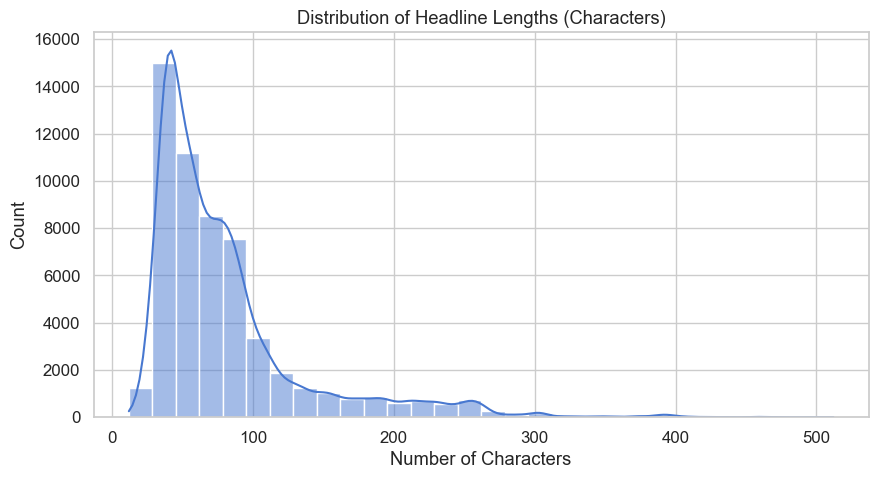

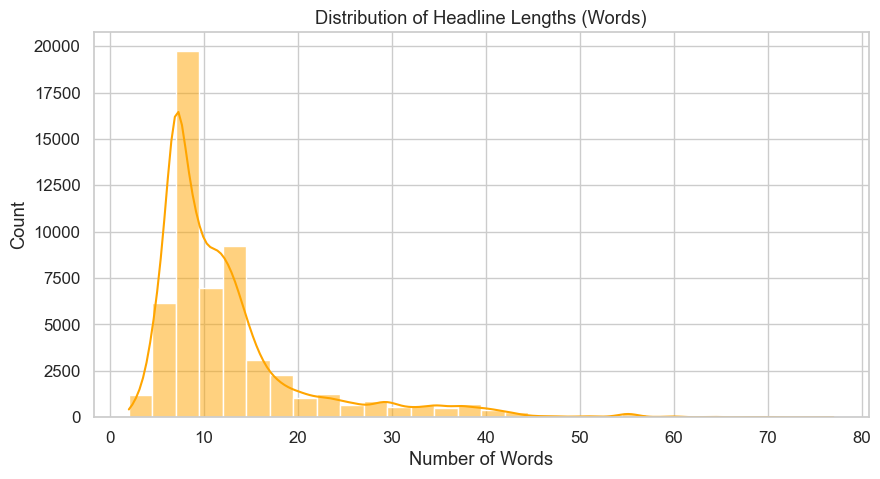


Top 10 Publishers by Number of Articles:
publisher
Benzinga Newsdesk    14750
Lisa Levin           12408
ETF Professor         4362
Paul Quintaro         4212
Benzinga Newsdesk     3177
Benzinga Insights     2332
Vick Meyer            2128
Charles Gross         1790
Hal Lindon            1470
Benzinga_Newsdesk     1239
Name: count, dtype: int64


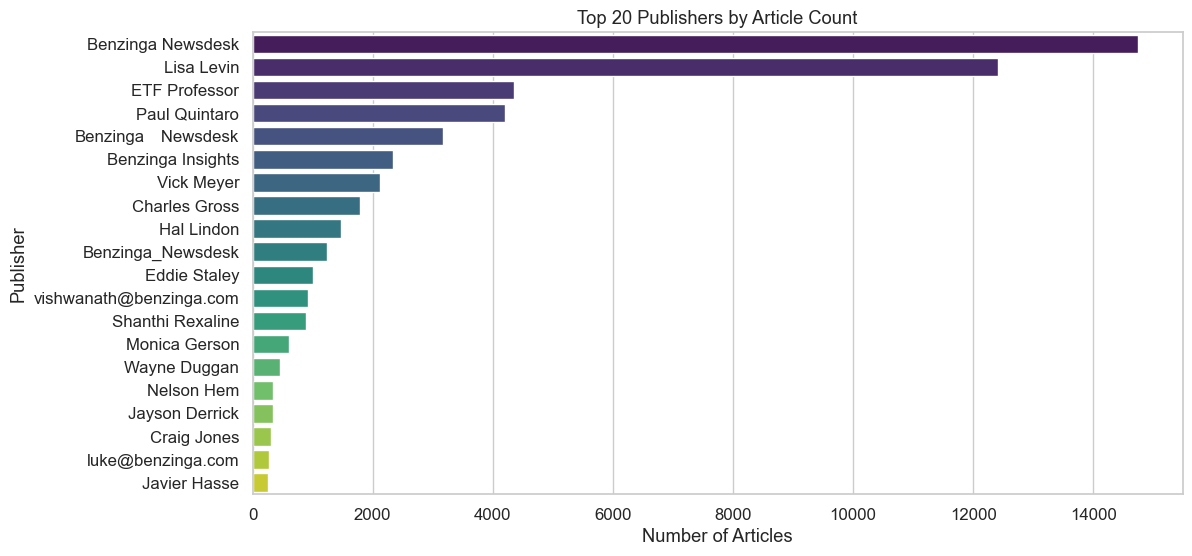


Sample daily article counts:
date_only
2011-04-27    1
2011-04-28    2
2011-04-29    2
2011-04-30    1
2011-05-01    1
2011-05-02    9
2011-05-03    3
2011-05-05    3
2011-05-06    3
2011-05-07    2
dtype: int64


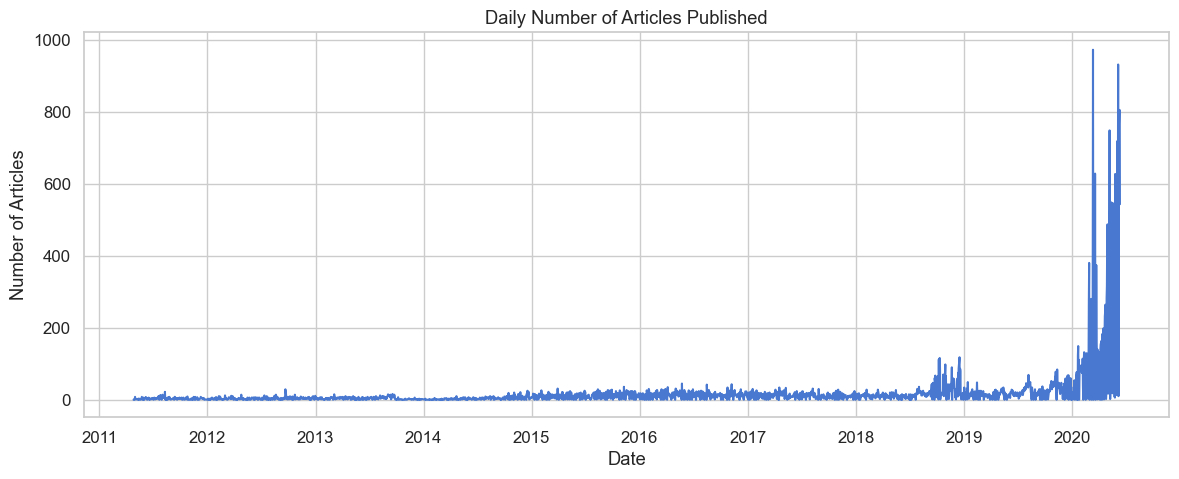

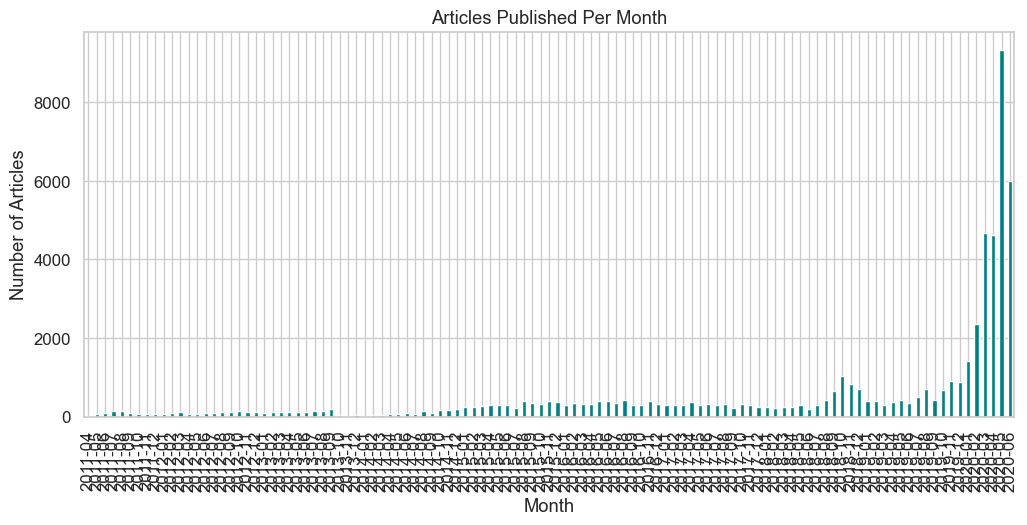

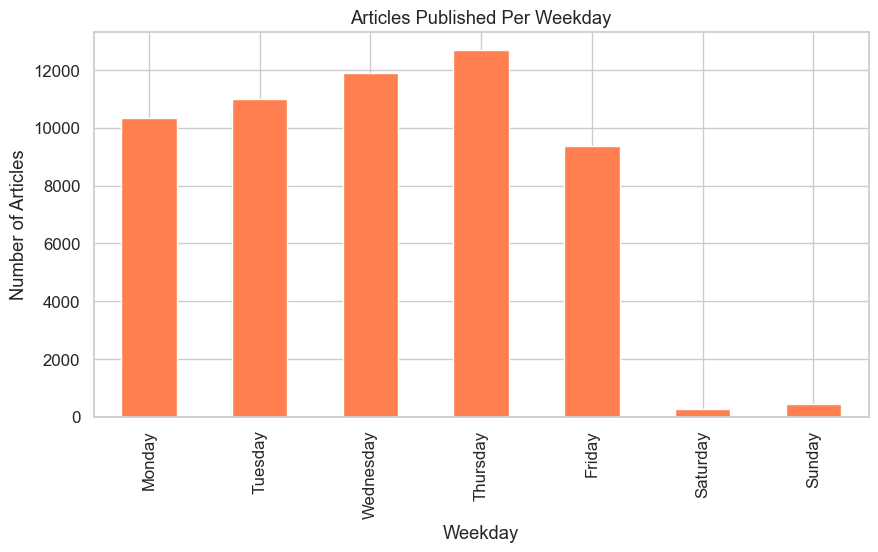

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="muted", font_scale=1.1)

# ---------- 1️⃣ Headline Length Statistics ----------
df['headline_length'] = df['headline'].str.len()              # characters
df['headline_word_count'] = df['headline'].str.split().str.len()  # words

print("Headline Length (Characters & Words):")
print(df[['headline_length', 'headline_word_count']].describe())

# Plot histogram of headline lengths
plt.figure(figsize=(10,5))
sns.histplot(df['headline_length'], bins=30, kde=True)
plt.title("Distribution of Headline Lengths (Characters)")
plt.xlabel("Number of Characters")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(df['headline_word_count'], bins=30, kde=True, color='orange')
plt.title("Distribution of Headline Lengths (Words)")
plt.xlabel("Number of Words")
plt.ylabel("Count")
plt.show()

# ---------- 2️⃣ Publisher Activity ----------
publisher_counts = df['publisher'].value_counts()
print("\nTop 10 Publishers by Number of Articles:")
print(publisher_counts.head(10))

# Plot top publishers
plt.figure(figsize=(12,6))
sns.barplot(x=publisher_counts.head(20).values, y=publisher_counts.head(20).index, palette="viridis")
plt.title("Top 20 Publishers by Article Count")
plt.xlabel("Number of Articles")
plt.ylabel("Publisher")
plt.show()

# ---------- 3️⃣ Publication Trends Over Time ----------
# Convert date column to date only
df['date_only'] = df['date'].dt.date

# Count articles per day
daily_counts = df.groupby('date_only').size()

print("\nSample daily article counts:")
print(daily_counts.head(10))

# Plot daily publication trend
plt.figure(figsize=(14,5))
daily_counts.plot()
plt.title("Daily Number of Articles Published")
plt.xlabel("Date")
plt.ylabel("Number of Articles")
plt.show()

# Optional: Top months or weekdays
df['month'] = df['date'].dt.to_period('M')
df['weekday'] = df['date'].dt.day_name()

month_counts = df.groupby('month').size()
weekday_counts = df.groupby('weekday').size()

plt.figure(figsize=(12,5))
month_counts.plot(kind='bar', color='teal')
plt.title("Articles Published Per Month")
plt.xlabel("Month")
plt.ylabel("Number of Articles")
plt.show()

plt.figure(figsize=(10,5))
weekday_counts.reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']).plot(kind='bar', color='coral')
plt.title("Articles Published Per Weekday")
plt.xlabel("Weekday")
plt.ylabel("Number of Articles")
plt.show()


## Step 3: Text Analysis (Topic Modeling)

Objective:
Use NLP techniques to identify common keywords, phrases, and latent topics in financial news headlines. This helps highlight recurring events like “FDA approval”, “price target changes”, or “earnings report”.

In [23]:
# -------------------------------
# Step 3: Text Analysis / Topic Modeling
# -------------------------------

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

# Ensure df is loaded and has 'headline'
text_data = df['headline'].dropna().str.lower()  # lowercase for consistency

# 1️⃣ TF-IDF Vectorization
vectorizer = TfidfVectorizer(
    max_df=0.95,        # ignore very common words
    min_df=5,           # ignore very rare words
    stop_words='english', 
    ngram_range=(1,2)   # unigrams and bigrams
)
tfidf = vectorizer.fit_transform(text_data)
print("TF-IDF matrix shape:", tfidf.shape)

# 2️⃣ Topic Modeling with NMF
n_topics = 5
nmf_model = NMF(n_components=n_topics, random_state=42)
nmf_model.fit(tfidf)

# 3️⃣ Extract top words per topic
feature_names = vectorizer.get_feature_names_out()
for topic_idx, topic in enumerate(nmf_model.components_):
    top_words = [feature_names[i] for i in topic.argsort()[:-11:-1]]  # top 10 words
    print(f"Topic {topic_idx+1}: {', '.join(top_words)}")

# 4️⃣ Assign dominant topic to each headline
topic_distribution = nmf_model.transform(tfidf)
df['dominant_topic'] = topic_distribution.argmax(axis=1)

# 5️⃣ Preview
print("\nSample headlines with dominant topics:")
print(df[['headline', 'dominant_topic']].head(10))


TF-IDF matrix shape: (55987, 19749)
Topic 1: week lows, lows, stocks hit, hit 52, hit, 52 week, 52, week, lows thursday, thursday
Topic 2: new 52, set new, stocks set, set, new, week low, low, low yesterday, yesterday, 52 week
Topic 3: stocks moving, moving, session, stocks, mid day, day, day session, mid, market session, pre market
Topic 4: week highs, highs, stocks hit, hit 52, hit, 52 week, 52, week, stocks, highs friday
Topic 5: movers, biggest movers, biggest, movers yesterday, yesterday, movers friday, friday, 70 biggest, 70, 72 biggest

Sample headlines with dominant topics:
                                            headline  dominant_topic
0            Stocks That Hit 52-Week Highs On Friday               3
1         Stocks That Hit 52-Week Highs On Wednesday               3
2                      71 Biggest Movers From Friday               4
3       46 Stocks Moving In Friday's Mid-Day Session               2
4  B of A Securities Maintains Neutral on Agilent...              

## Step 4: Time Series Analysis

Objective:
Analyze publication frequency over time to detect patterns or spikes. Understanding when news is released is critical for trading strategies and automated systems.

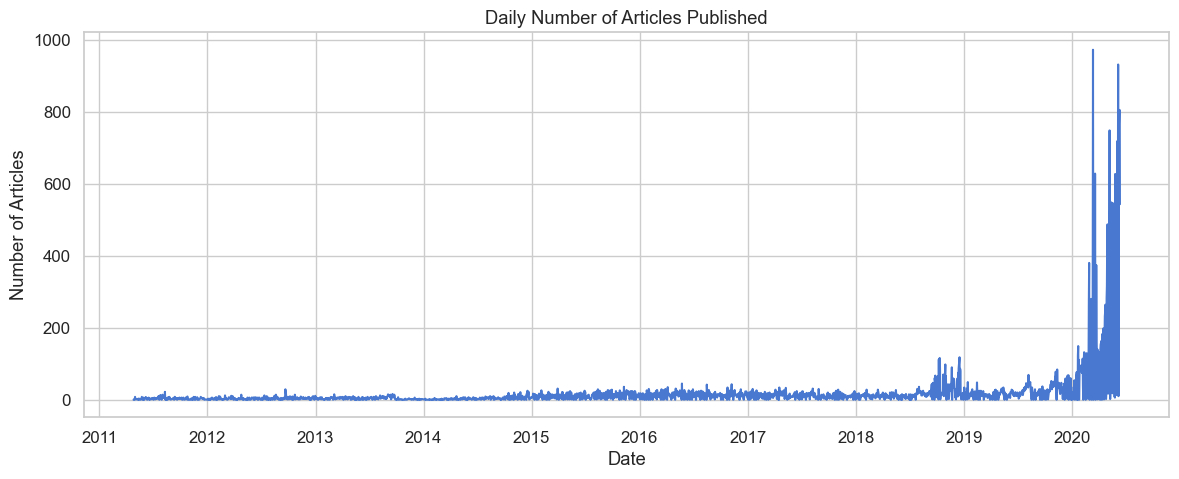

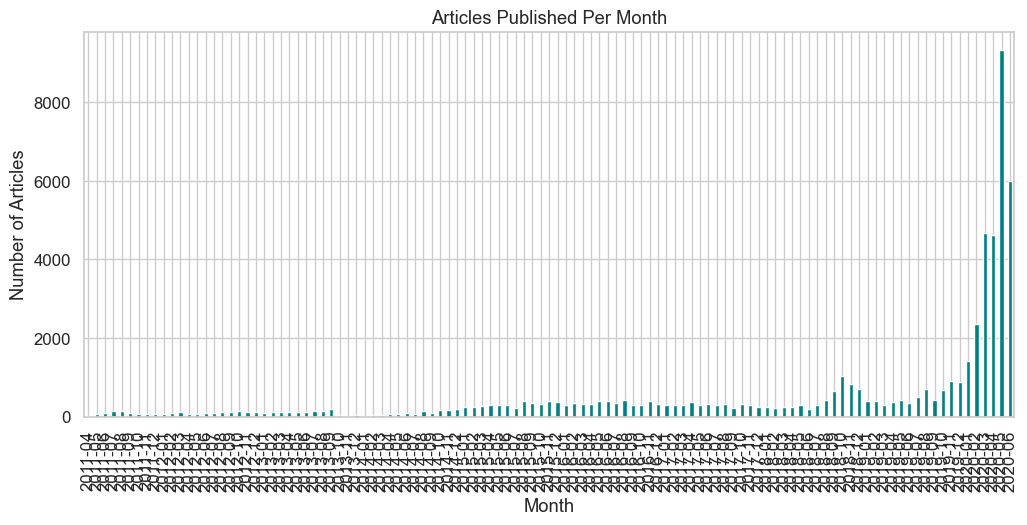

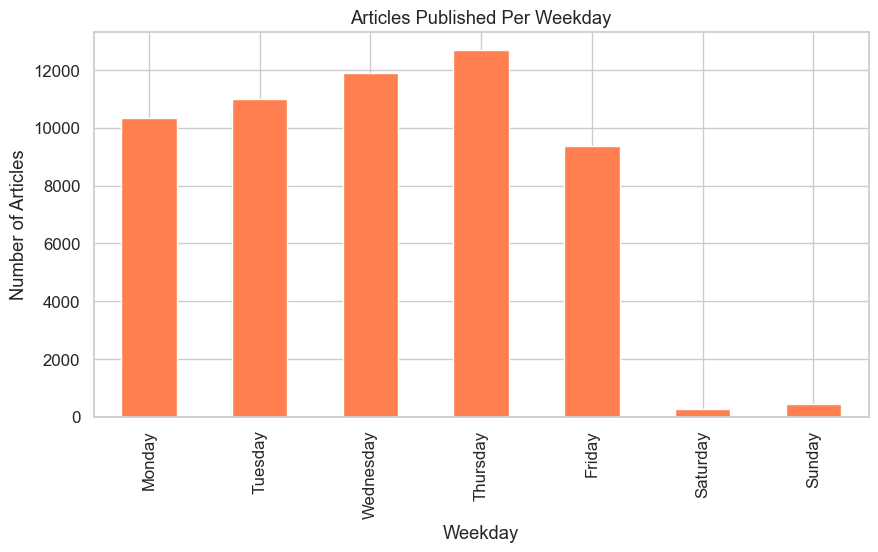

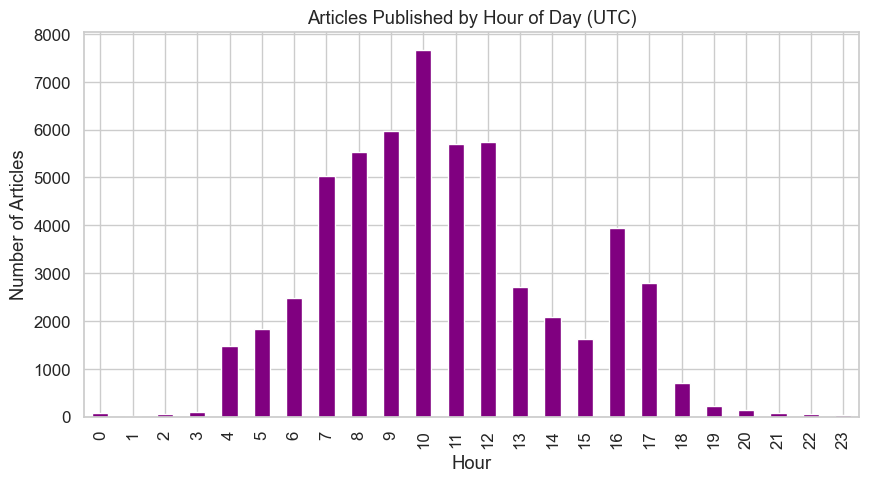

In [24]:
# -------------------------------
# Step 4: Time Series Analysis
# -------------------------------

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="muted", font_scale=1.1)

# Ensure 'date' column is datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# ---------- 1️⃣ Daily Publication Frequency ----------
df['date_only'] = df['date'].dt.date
daily_counts = df.groupby('date_only').size()

plt.figure(figsize=(14,5))
daily_counts.plot()
plt.title("Daily Number of Articles Published")
plt.xlabel("Date")
plt.ylabel("Number of Articles")
plt.show()

# ---------- 2️⃣ Monthly Trends ----------
df['month'] = df['date'].dt.to_period('M')
month_counts = df.groupby('month').size()

plt.figure(figsize=(12,5))
month_counts.plot(kind='bar', color='teal')
plt.title("Articles Published Per Month")
plt.xlabel("Month")
plt.ylabel("Number of Articles")
plt.show()

# ---------- 3️⃣ Weekday Trends ----------
df['weekday'] = df['date'].dt.day_name()
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_counts = df['weekday'].value_counts().reindex(weekday_order)

plt.figure(figsize=(10,5))
weekday_counts.plot(kind='bar', color='coral')
plt.title("Articles Published Per Weekday")
plt.xlabel("Weekday")
plt.ylabel("Number of Articles")
plt.show()

# ---------- 4️⃣ Hourly Trends ----------
df['hour'] = df['date'].dt.hour
hourly_counts = df.groupby('hour').size()

plt.figure(figsize=(10,5))
hourly_counts.plot(kind='bar', color='purple')
plt.title("Articles Published by Hour of Day (UTC)")
plt.xlabel("Hour")
plt.ylabel("Number of Articles")
plt.show()


## Step 5: Publisher Analysis

Objective:

Identify which publishers contribute the most news articles.

Analyze if there are differences in coverage.

If email addresses are used as publisher names, extract domains to see organizational patterns

Top 10 publishers by number of articles:
publisher
Benzinga Newsdesk    14750
Lisa Levin           12408
ETF Professor         4362
Paul Quintaro         4212
Benzinga Newsdesk     3177
Benzinga Insights     2332
Vick Meyer            2128
Charles Gross         1790
Hal Lindon            1470
Benzinga_Newsdesk     1239
Name: count, dtype: int64


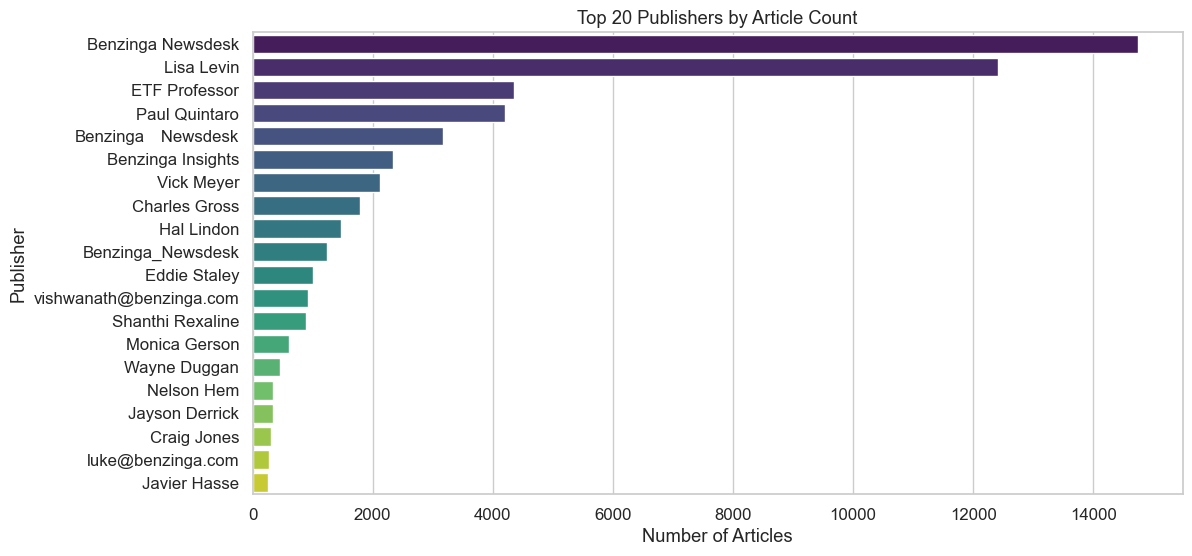


Top 10 publisher domains:
publisher_domain
Benzinga Newsdesk    14750
Lisa Levin           12408
ETF Professor         4362
Paul Quintaro         4212
Benzinga Newsdesk     3177
Benzinga Insights     2332
Vick Meyer            2128
Charles Gross         1790
Hal Lindon            1470
Benzinga_Newsdesk     1239
Name: count, dtype: int64


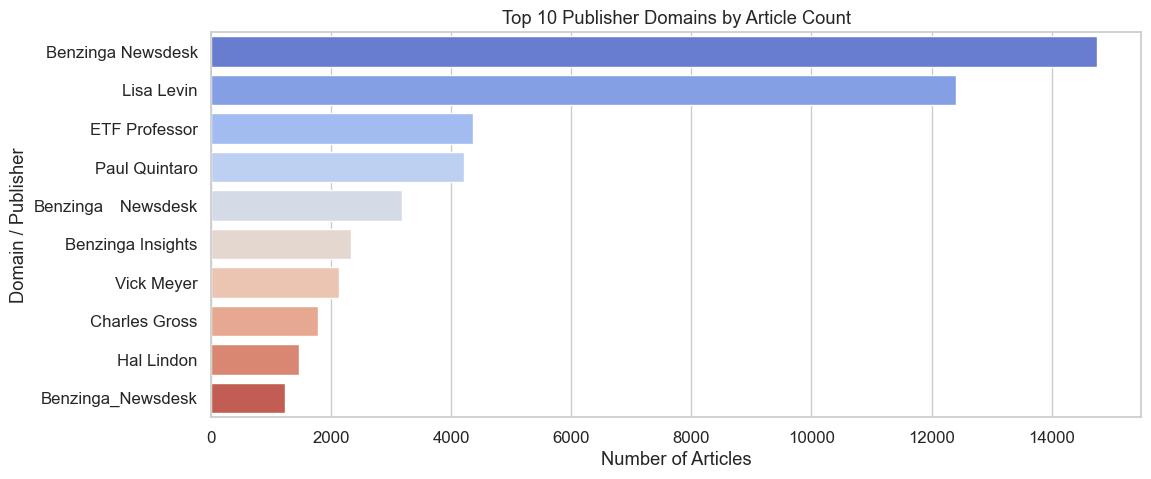

In [25]:
# -------------------------------
# Step 5: Publisher Analysis
# -------------------------------

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set(style="whitegrid", palette="muted", font_scale=1.1)

# ---------- 1️⃣ Count Articles per Publisher ----------
publisher_counts = df['publisher'].value_counts()
print("Top 10 publishers by number of articles:")
print(publisher_counts.head(10))

# Plot top 20 publishers
plt.figure(figsize=(12,6))
sns.barplot(x=publisher_counts.head(20).values, y=publisher_counts.head(20).index, palette="viridis")
plt.title("Top 20 Publishers by Article Count")
plt.xlabel("Number of Articles")
plt.ylabel("Publisher")
plt.show()

# ---------- 2️⃣ Extract Domains from Email-style Publisher Names ----------
def extract_domain(publisher):
    if pd.isna(publisher):
        return None
    match = re.search(r'@([\w\.-]+)', publisher)
    return match.group(1) if match else publisher  # fallback to original if not email

df['publisher_domain'] = df['publisher'].apply(extract_domain)

# Count articles per domain
domain_counts = df['publisher_domain'].value_counts()
print("\nTop 10 publisher domains:")
print(domain_counts.head(10))

# Plot top 10 domains
plt.figure(figsize=(12,5))
sns.barplot(x=domain_counts.head(10).values, y=domain_counts.head(10).index, palette="coolwarm")
plt.title("Top 10 Publisher Domains by Article Count")
plt.xlabel("Number of Articles")
plt.ylabel("Domain / Publisher")
plt.show()
